# NBA Sportsbook Calibration Analysis
### ECE 143 — Quantitative Forecasting: Sportsbook Calibration & Prediction Market API Constraints

This notebook presents all project visualizations in one place, covering:

1. **Dataset Overview** — shape, null counts, valid-odds coverage
2. **EDA (Phase 2)** — vig distribution, home win probabilities, games per season
3. **Sportsbook Calibration (Phase 3)** — reliability diagrams, Regular Season vs Playoffs, confidence tiers, seasonal trend
4. **Key Findings Summary**

**Dataset:** Kaggle NBA sportsbook odds (2008–2025), ~19,820 games with valid moneyline odds.

---

In [1]:
import sys
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

%matplotlib inline

# Suppress INFO-level logs so notebook output stays clean
logging.basicConfig(level=logging.WARNING)

from src.processing.quant_logic import apply_no_vig_probabilities
from src.processing.evaluation import run_evaluation

RAW_PATH = 'data/raw/nba_2008-2025.csv'
PROCESSED_DIR = 'data/processed'

---
## 1. Dataset Overview

In [2]:
df_raw = pd.read_csv(RAW_PATH)

print(f'Shape          : {df_raw.shape}')
print(f'Seasons covered: {df_raw["season"].min()} – {df_raw["season"].max()}')
print(f'\nNull counts (selected columns):')
print(df_raw[['moneyline_home', 'moneyline_away', 'spread', 'total']].isnull().sum().to_string())

n_valid = df_raw['moneyline_home'].notna().sum()
print(f'\nGames with valid moneylines : {n_valid:,} / {len(df_raw):,}  '
      f'({100 * n_valid / len(df_raw):.1f}% retained, '
      f'{100 * (1 - n_valid / len(df_raw)):.1f}% dropped)')

Shape          : (23118, 27)
Seasons covered: 2008 – 2025

Null counts (selected columns):
moneyline_home    3298
moneyline_away    3298
spread               3
total                0

Games with valid moneylines : 19,820 / 23,118  (85.7% retained, 14.3% dropped)


---
## 2. Exploratory Data Analysis (Phase 2)

Filter to games with valid moneyline odds and apply the no-vig conversion.

In [3]:
df = df_raw.dropna(subset=['moneyline_home', 'moneyline_away']).copy()
df = df.rename(columns={'moneyline_home': 'home_odds', 'moneyline_away': 'away_odds'})
df = apply_no_vig_probabilities(df)

vig_pct = (df['sportsbook_overround'] - 1) * 100
print('Sportsbook Vig Statistics (% overround above 100%)')
print(f'  Mean : {vig_pct.mean():.2f}%')
print(f'  Median: {vig_pct.median():.2f}%')
print(f'  Min  : {vig_pct.min():.2f}%')
print(f'  Max  : {vig_pct.max():.2f}%')

Sportsbook Vig Statistics (% overround above 100%)
  Mean : 3.77%
  Median: 3.76%
  Min  : -3.92%
  Max  : 73.33%


### 2.1  Vig Distribution (2008–2022)

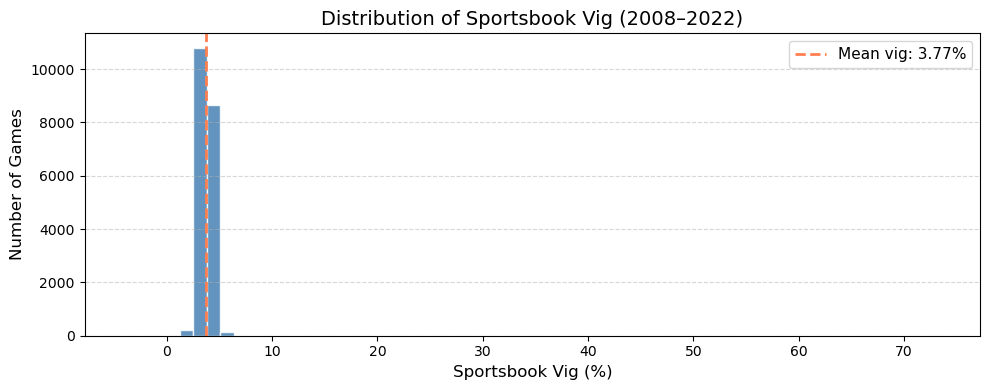

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(vig_pct, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(vig_pct.mean(), color='coral', linestyle='--', linewidth=2,
           label=f'Mean vig: {vig_pct.mean():.2f}%')
ax.set_xlabel('Sportsbook Vig (%)', fontsize=12)
ax.set_ylabel('Number of Games', fontsize=12)
ax.set_title('Distribution of Sportsbook Vig (2008–2022)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()

### 2.2  Fair Home Win Probability Distribution

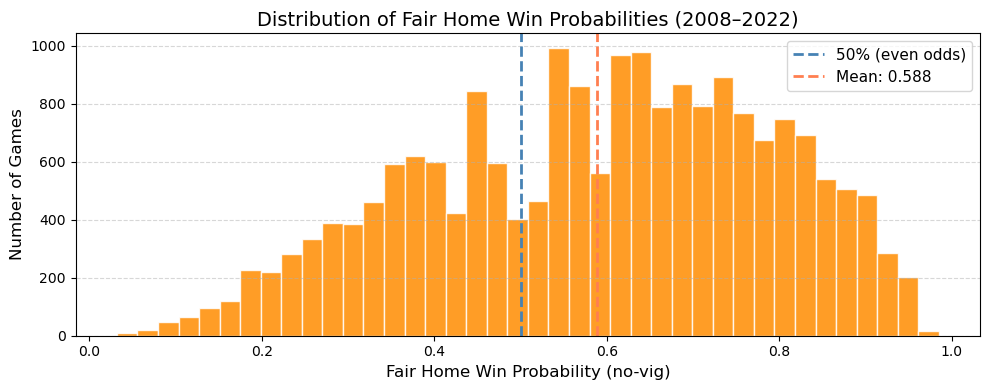

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['fair_prob_home'], bins=40, color='darkorange', edgecolor='white', alpha=0.85)
ax.axvline(0.5, color='steelblue', linestyle='--', linewidth=2, label='50% (even odds)')
ax.axvline(df['fair_prob_home'].mean(), color='coral', linestyle='--', linewidth=2,
           label=f'Mean: {df["fair_prob_home"].mean():.3f}')
ax.set_xlabel('Fair Home Win Probability (no-vig)', fontsize=12)
ax.set_ylabel('Number of Games', fontsize=12)
ax.set_title('Distribution of Fair Home Win Probabilities (2008–2022)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()

### 2.3  Games per Season with Valid Moneylines

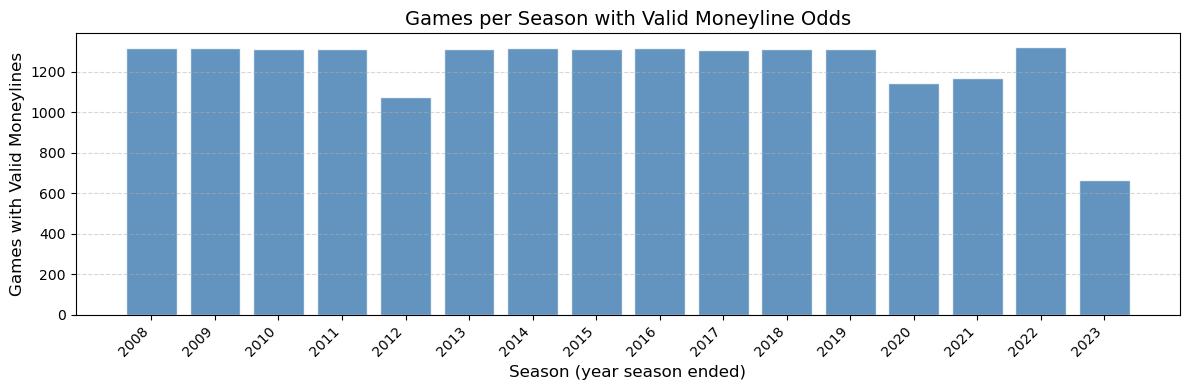

Note: 2024–2025 have no moneylines in this dataset. 2023 is partial.


In [6]:
games_per_season = df.groupby('season').size()

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(games_per_season.index.astype(str), games_per_season.values,
              color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('Season (year season ended)', fontsize=12)
ax.set_ylabel('Games with Valid Moneylines', fontsize=12)
ax.set_title('Games per Season with Valid Moneyline Odds', fontsize=14)
plt.xticks(rotation=45, ha='right')
ax.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()

print('Note: 2024–2025 have no moneylines in this dataset. 2023 is partial.')

---
## 3. Sportsbook Calibration Evaluation (Phase 3)

Runs the full evaluation pipeline on ~19,820 games and generates four plots:
- Overall reliability diagram
- Regular Season vs Playoffs
- Confidence tiers (strong / moderate / coin-flip)
- Brier Score trend by season with 95% bootstrap CI

**Metrics:** Brier Score (mean squared error of probabilities vs outcomes) and Log Loss. Both are *proper scoring rules* — the only way to improve them is with better-calibrated probabilities.

In [7]:
df_eval = run_evaluation(source='kaggle')


  ECE 143 — Sportsbook Calibration & Evaluation (Sportsbook-Only)

  Dataset : Kaggle raw (nba_2008-2025.csv)
  Games   : 19,820

  ── Overall Metrics (lower is better) ──────────────────────────────────
  Brier Score : 0.2024  [0.2000, 0.2047]  (95% bootstrap CI)
  Log Loss    : 0.5893

  ── By Game Type ───────────────────────────────────────────────────────
  Regular Season    : Brier = 0.2021  (N = 18,550)
  Playoffs          : Brier = 0.2062  (N = 1,257)

  ── By Prediction Confidence ───────────────────────────────────────────
  Strong fav  (≥65%)        : Brier = 0.1717  (N = 11,291)
  Moderate fav (55–65%)     : Brier = 0.2404  (N = 5,970)
  Near coin-flip (<55%)     : Brier = 0.2491  (N = 2,559)

  ── Output Files ───────────────────────────────────────────────────────
  sportsbook_calibration.png     (overall calibration curve)
  segmented_by_game_type.png     (Regular Season vs Playoffs)
  segmented_by_favorite.png      (confidence tiers)
  brier_by_season.png            (s

### 3.1  Overall Probability Calibration Curve (Reliability Diagram)

Points on the diagonal = perfect calibration. The closer to the diagonal, the more accurate the sportsbook's implied probabilities are.

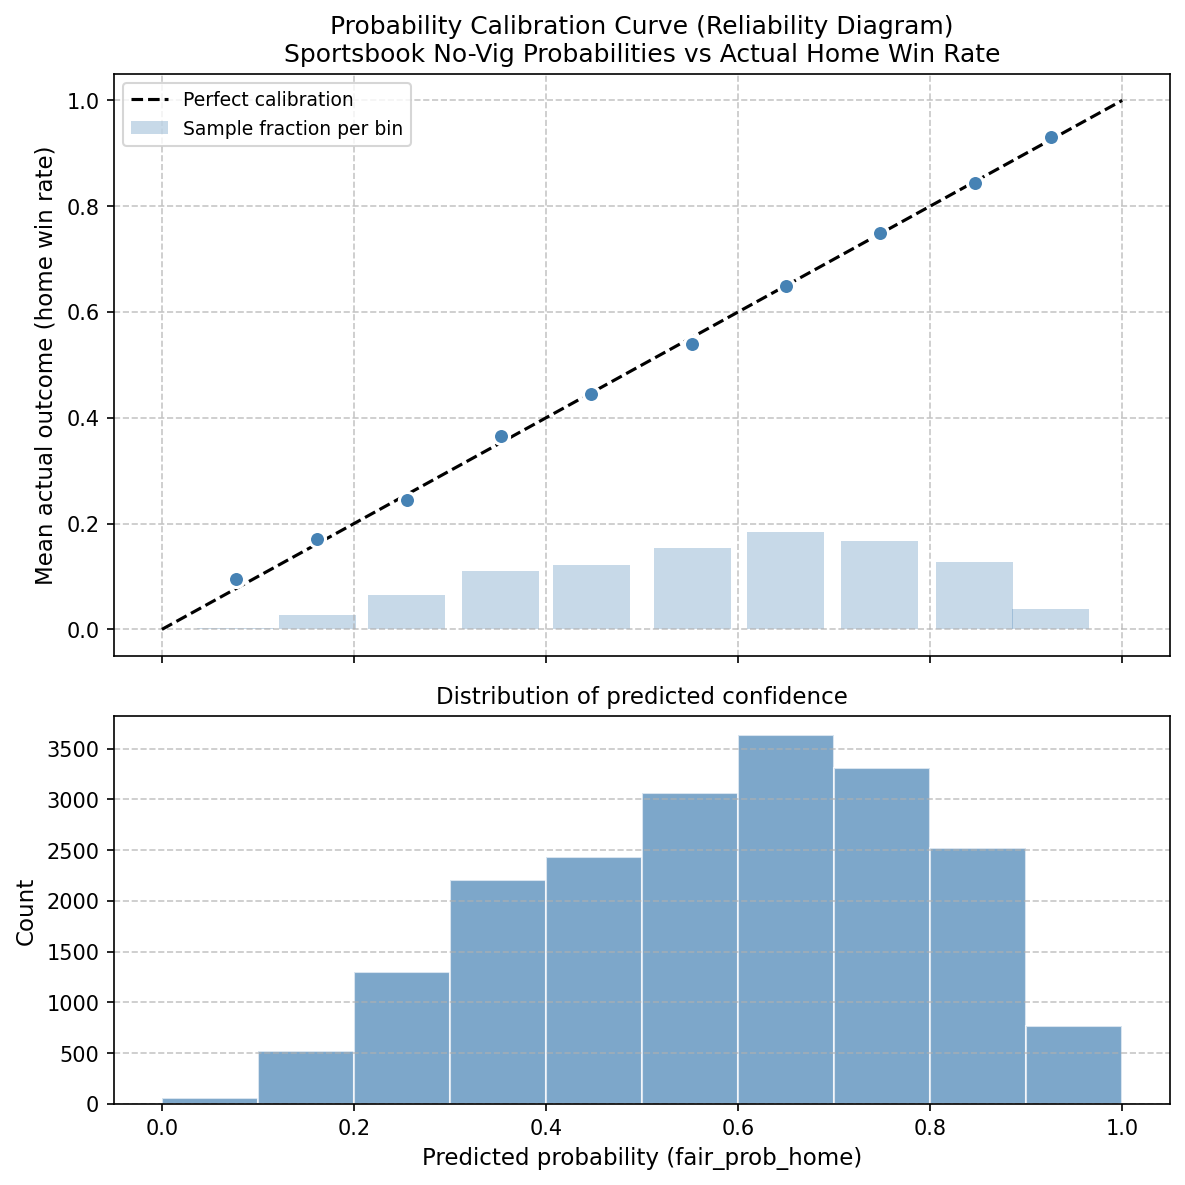

In [8]:
display(Image(filename=f'{PROCESSED_DIR}/sportsbook_calibration.png', width=700))

### 3.2  Calibration: Regular Season vs Playoffs

Compares calibration quality between the 18,550 regular-season games and 1,257 playoff games.

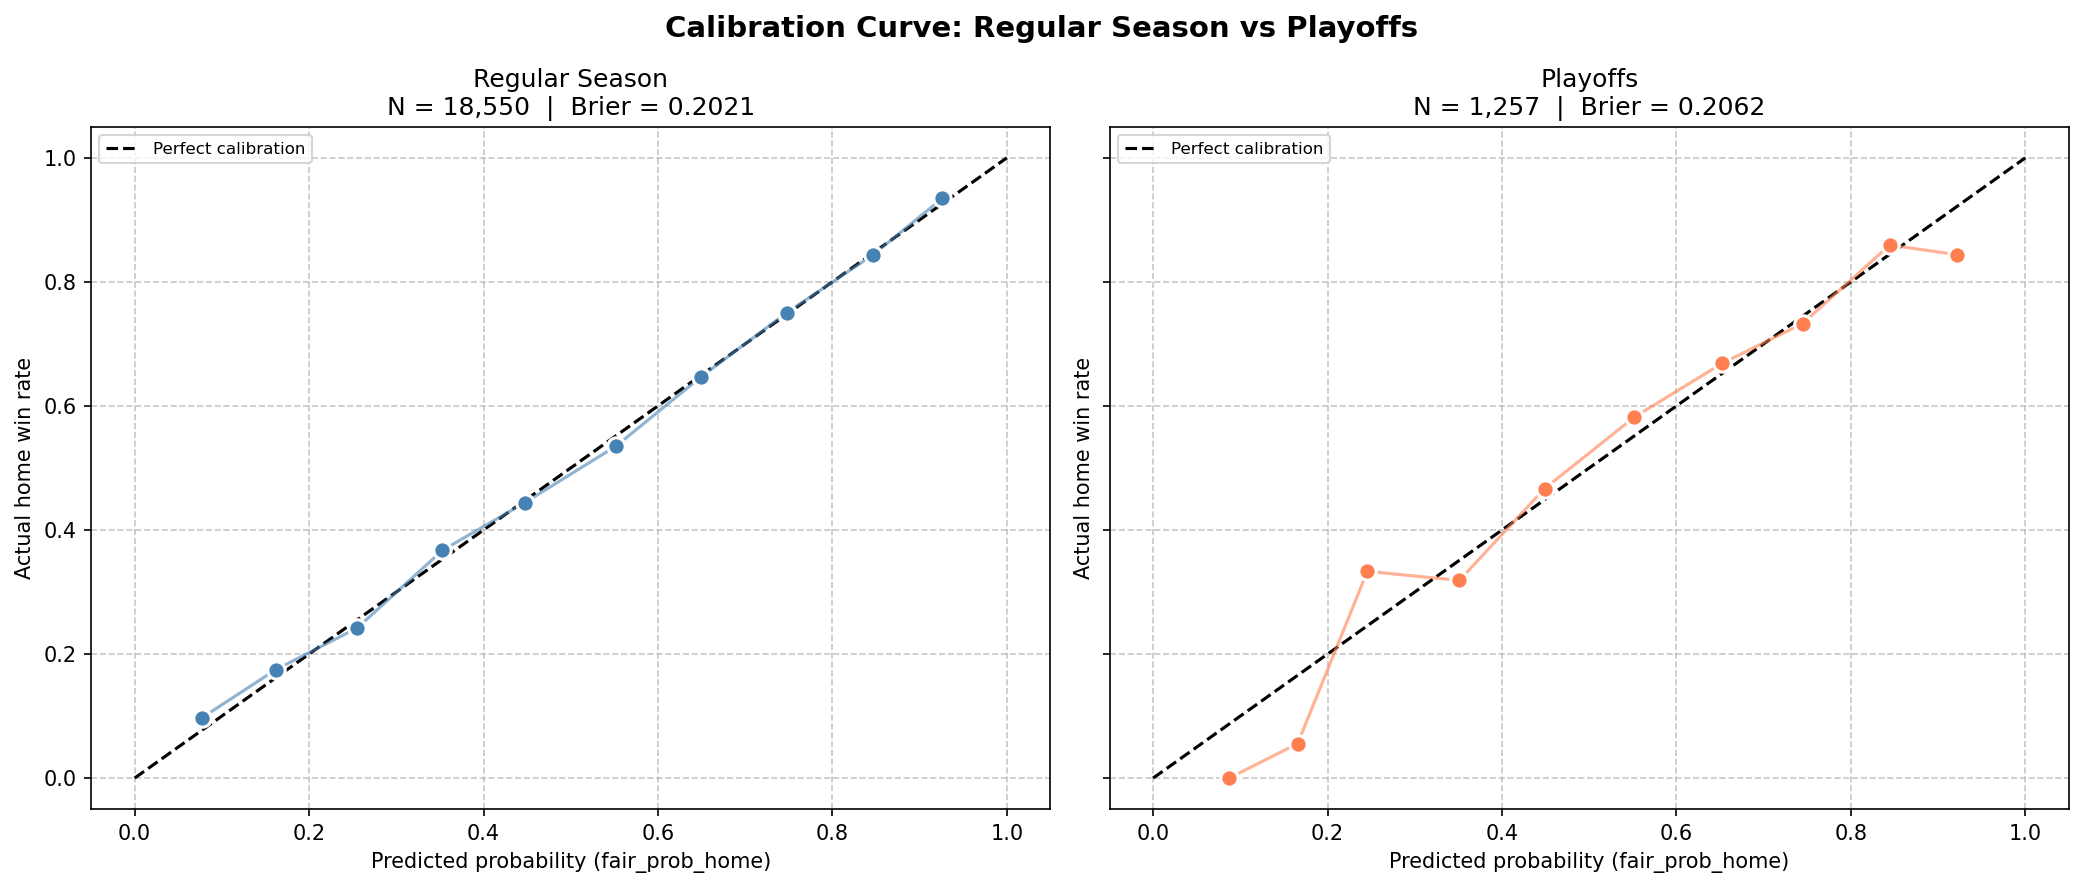

In [9]:
display(Image(filename=f'{PROCESSED_DIR}/segmented_by_game_type.png', width=900))

### 3.3  Calibration by Prediction Confidence Tier

Games grouped by how confident the sportsbook is (regardless of which team is favoured):
- **Strong fav (≥65%)** — sportsbook is very confident
- **Moderate fav (55–65%)** — clear but not dominant favourite
- **Near coin-flip (<55%)** — sportsbook sees a near-even contest

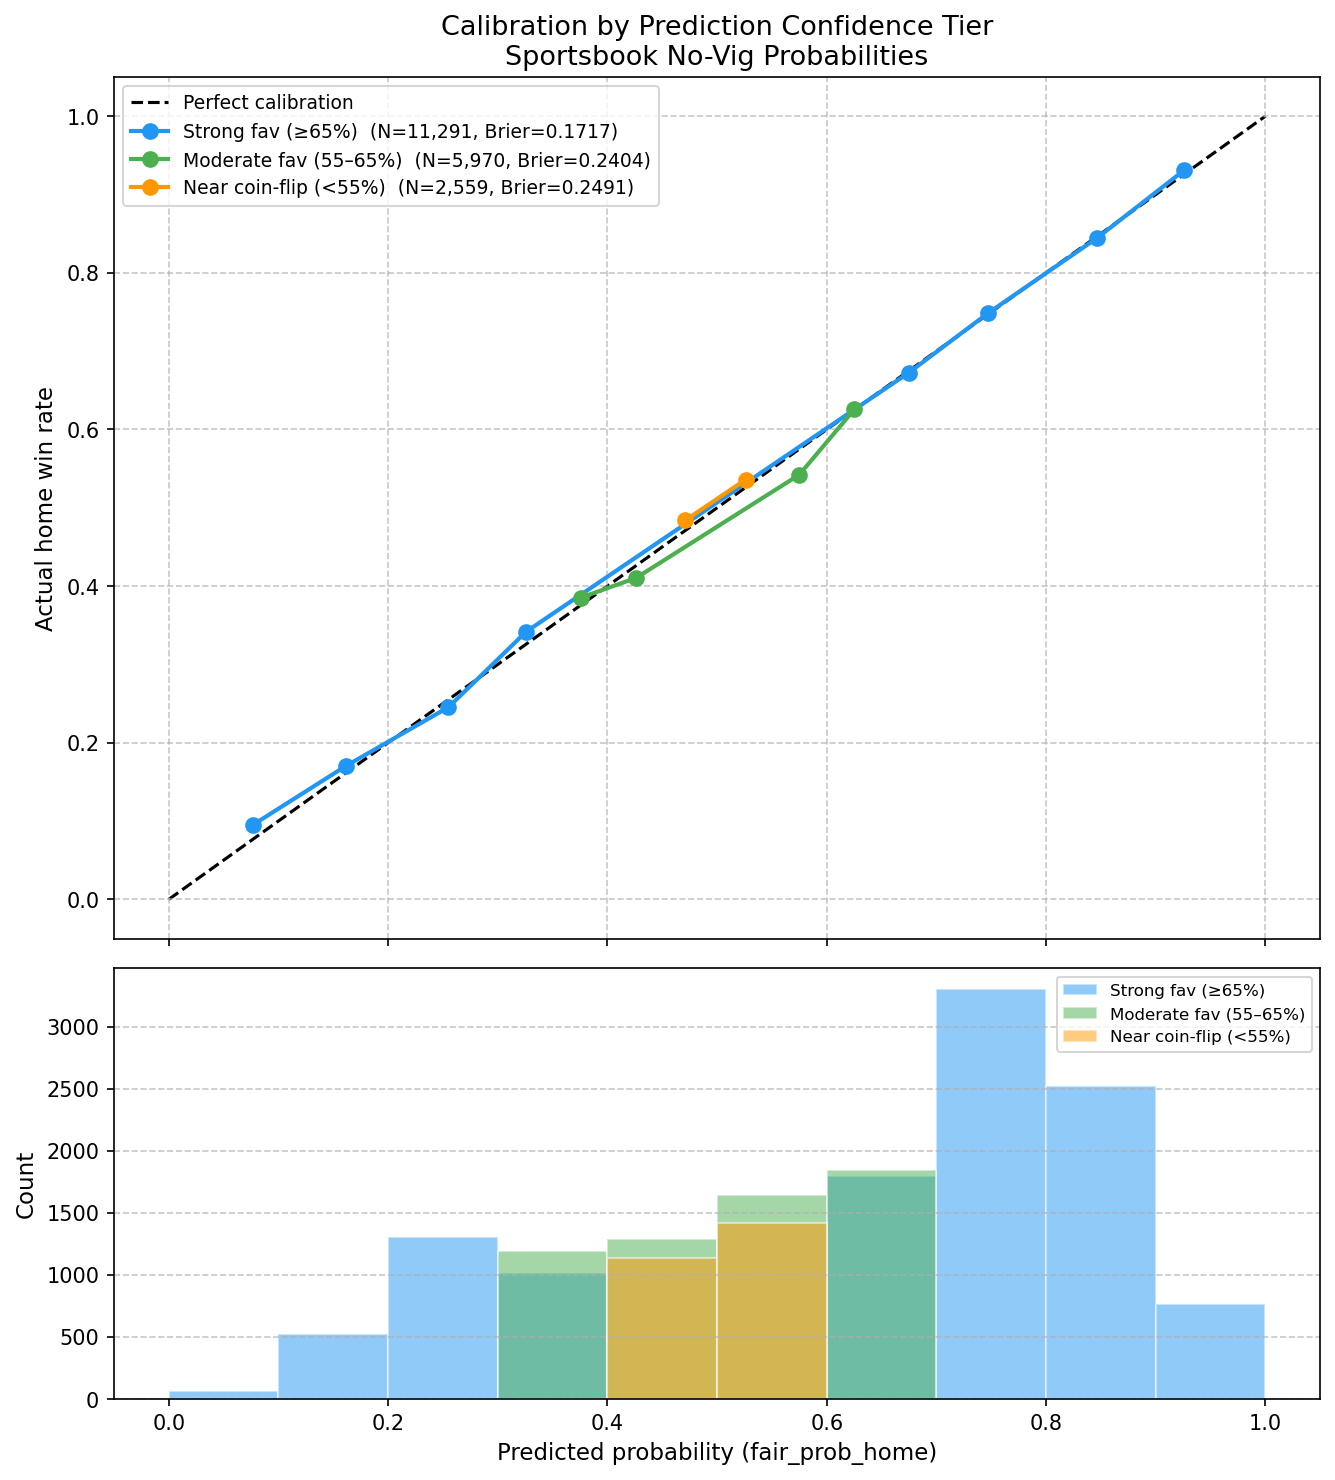

In [10]:
display(Image(filename=f'{PROCESSED_DIR}/segmented_by_favorite.png', width=750))

### 3.4  Brier Score Trend by Season (2008–2022)

Error bars show 95% bootstrap confidence intervals. The coral dashed line is the overall mean.

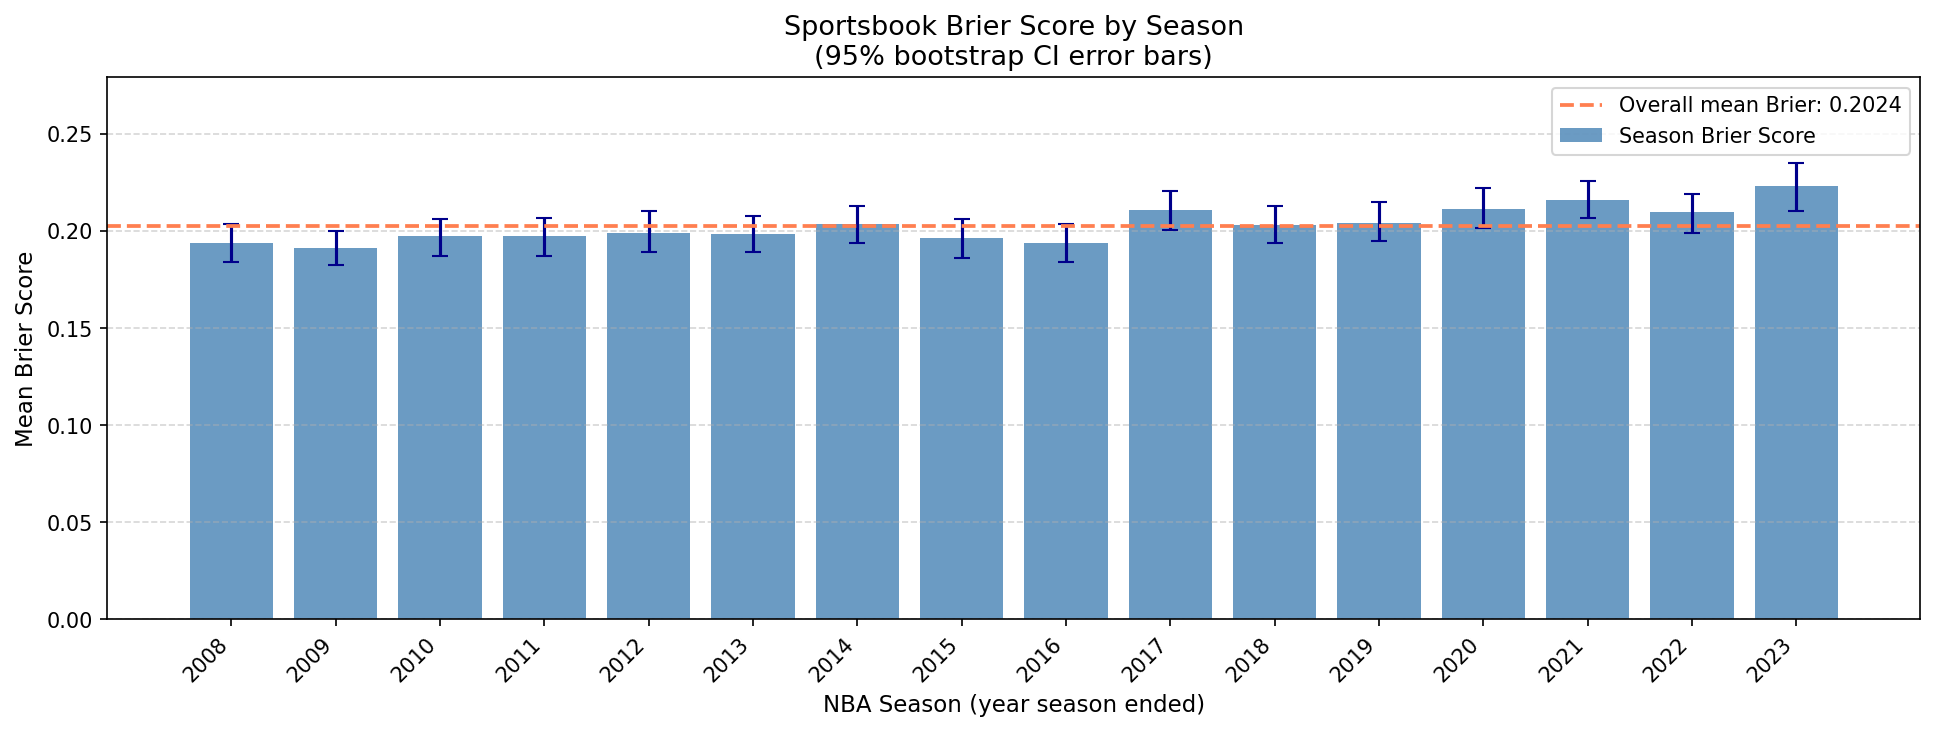

In [11]:
display(Image(filename=f'{PROCESSED_DIR}/brier_by_season.png', width=900))

---
## 4. Key Findings

| Segment | Brier Score | N | Interpretation |
|---|---|---|---|
| **Overall** | **0.2024** [0.2000, 0.2047] | 19,820 | Better than random baseline (0.25) |
| Regular Season | 0.2021 | 18,550 | Consistent calibration |
| Playoffs | 0.2062 | 1,257 | Slightly harder to predict |
| Strong fav (≥65%) | **0.1717** | 11,291 | Sportsbook is significantly accurate |
| Moderate fav (55–65%) | 0.2404 | 5,970 | Modest edge |
| Near coin-flip (<55%) | **0.2491** | 2,559 | Virtually no edge over random |

### Summary

1. **Sportsbooks add real value.** A Brier Score of 0.2024 meaningfully beats the 0.25 baseline of always predicting 50/50.

2. **Predictive edge is concentrated in clear mismatches.** For strong favourites (≥65%), Brier = 0.1717 — well below random. For near coin-flips, Brier = 0.2491 — essentially random. The sportsbook's skill is in identifying unequal matchups, not in splitting closely contested games.

3. **Calibration is stable over time.** The seasonal Brier trend shows no systematic drift across 2008–2022, with CIs overlapping the overall mean for all seasons.

4. **Polymarket API Limitation (Engineering Finding).** The original goal was to compare sportsbook probabilities against Polymarket prediction market prices at T−1 hour before tip-off. This was not possible because:
   - Polymarket's CLOB `/prices-history` endpoint returns empty `{"history": []}` for closed markets (data purged).
   - Terminal `outcomePrices` from the Gamma API are 0.0 or 1.0 (resolution prices), not pre-game probabilities.
   - No individual NBA game markets were found — only season-long futures.
   
   This is a meaningful finding about the current state of decentralised prediction markets as a data source for retrospective analysis.